![lop](../../images/logo_diive1_128px.png)

<span style='font-size:40px; display:block;'>
<b>
    Vectorize timestamps  
</b>  
</span>
Add date attributes as columns to dataframe

---
**Notebook version**: `1` (5 Jan 2026)  
**Author**: Lukas Hörtnagl (holukas@ethz.ch) 

# Description

- Expands a DateTimeIndex into linear and cyclical (sin/cos) features
- Timestamp info is added as new columns to the dataframe

</br>

# Imports

In [1]:
import importlib.metadata
from datetime import datetime
from diive.core.times.times import vectorize_timestamps
from diive.configs.exampledata import load_exampledata_parquet

version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# Docstring

In [2]:
help(vectorize_timestamps)

Help on function vectorize_timestamps in module diive.core.times.times:

vectorize_timestamps(df, year: bool = True, season: bool = True, month: bool = True, week: bool = True, doy: bool = True, hour: bool = True, txt: str = '', verbose: int = 1) -> pandas.core.frame.DataFrame
    Vectorizes a DatetimeIndex into linear and cyclical (sin/cos) numerical features.
    
    This function "vectorizes" time by mapping periodic date components (like month or
    hour) into 2D space using sine and cosine transformations. This ensures that
    cyclical proximity (e.g., December and January, or 23:00 and 00:00) is preserved
    geometrically for machine learning models.
    
    Kudos:
    - https://datascience.stackexchange.com/questions/60951/is-it-necessary-to-convert-labels-in-string-to-integer-for-scikit-learn-and-xgbo
    - https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
    
    Args:
        df (DataFrame): Input DataFrame with a DatetimeIndex.


</br>

# Load example data with timestamp index

In [3]:
df = load_exampledata_parquet()
df = df.loc[(df.index.year == 2016) & (df.index.month >= 7) & (df.index.month <= 9)].copy()
df = df[['NEE_CUT_REF_f']].copy()
df

Loaded .parquet file F:\Sync\luhk_work\20 - CODING\21 - DIIVE\diive\diive\configs\exampledata\exampledata_PARQUET_CH-DAV_FP2022.5_2013-2022_ID20230206154316_30MIN.parquet (0.274 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_CUT_REF_f
TIMESTAMP_MIDDLE,
2016-07-01 00:15:00,5.530
2016-07-01 00:45:00,5.460
2016-07-01 01:15:00,5.164
2016-07-01 01:45:00,4.282
2016-07-01 02:15:00,4.165
...,...
2016-09-30 21:45:00,3.569
2016-09-30 22:15:00,3.569
2016-09-30 22:45:00,2.805


</br>

# Vectorize timestamps

In [4]:
new_df = vectorize_timestamps(
    df=df.copy(),
    year=True, 
    season=True,
    month=True,
    week=True,
    doy=True,
    hour=True
)
new_df

++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 


,NEE_CUT_REF_f,.YEAR,.SEASON,.SEASON_SIN,.SEASON_COS,.MONTH,.MONTH_SIN,.MONTH_COS,.WEEK,.WEEK_SIN,.WEEK_COS,.DOY,.DOY_SIN,.DOY_COS,.HOUR,.HOUR_SIN,.HOUR_COS,.YEARMONTH,.YEARDOY,.YEARWEEK
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,
2016-07-01 00:15:00,5.530,2016,2,1.224647e-16,-1.000000e+00,7,-0.5,-8.660254e-01,26,0.059241,-0.998244,183,-0.006451,-0.999979,0,0.000000,1.000000,201607,2016183,201626
2016-07-01 00:45:00,5.460,2016,2,1.224647e-16,-1.000000e+00,7,-0.5,-8.660254e-01,26,0.059241,-0.998244,183,-0.006451,-0.999979,0,0.000000,1.000000,201607,2016183,201626
2016-07-01 01:15:00,5.164,2016,2,1.224647e-16,-1.000000e+00,7,-0.5,-8.660254e-01,26,0.059241,-0.998244,183,-0.006451,-0.999979,1,0.258819,0.965926,201607,2016183,201626
2016-07-01 01:45:00,4.282,2016,2,1.224647e-16,-1.000000e+00,7,-0.5,-8.660254e-01,26,0.059241,-0.998244,183,-0.006451,-0.999979,1,0.258819,0.965926,201607,2016183,201626
2016-07-01 02:15:00,4.165,2016,2,1.224647e-16,-1.000000e+00,7,-0.5,-8.660254e-01,26,0.059241,-0.998244,183,-0.006451,-0.999979,2,0.500000,0.866025,201607,2016183,201626
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-30 21:45:00,3.569,2016,3,-1.000000e+00,-1.836970e-16,9,-1.0,-1.836970e-16,39,-0.996050,-0.088796,274,-0.999999,0.001075,21,-0.707107,0.707107,201609,2016274,201639
2016-09-30 22:15:00,3.569,2016,3,-1.000000e+00,-1.836970e-16,9,-1.0,-1.836970e-16,39,-0.996050,-0.088796,274,-0.999999,0.001075,22,-0.500000,0.866025,201609,2016274,201639
2016-09-30 22:45:00,2.805,2016,3,-1.000000e+00,-1.836970e-16,9,-1.0,-1.836970e-16,39,-0.996050,-0.088796,274,-0.999999,0.001075,22,-0.500000,0.866025,201609,2016274,201639


</br>

# Plot

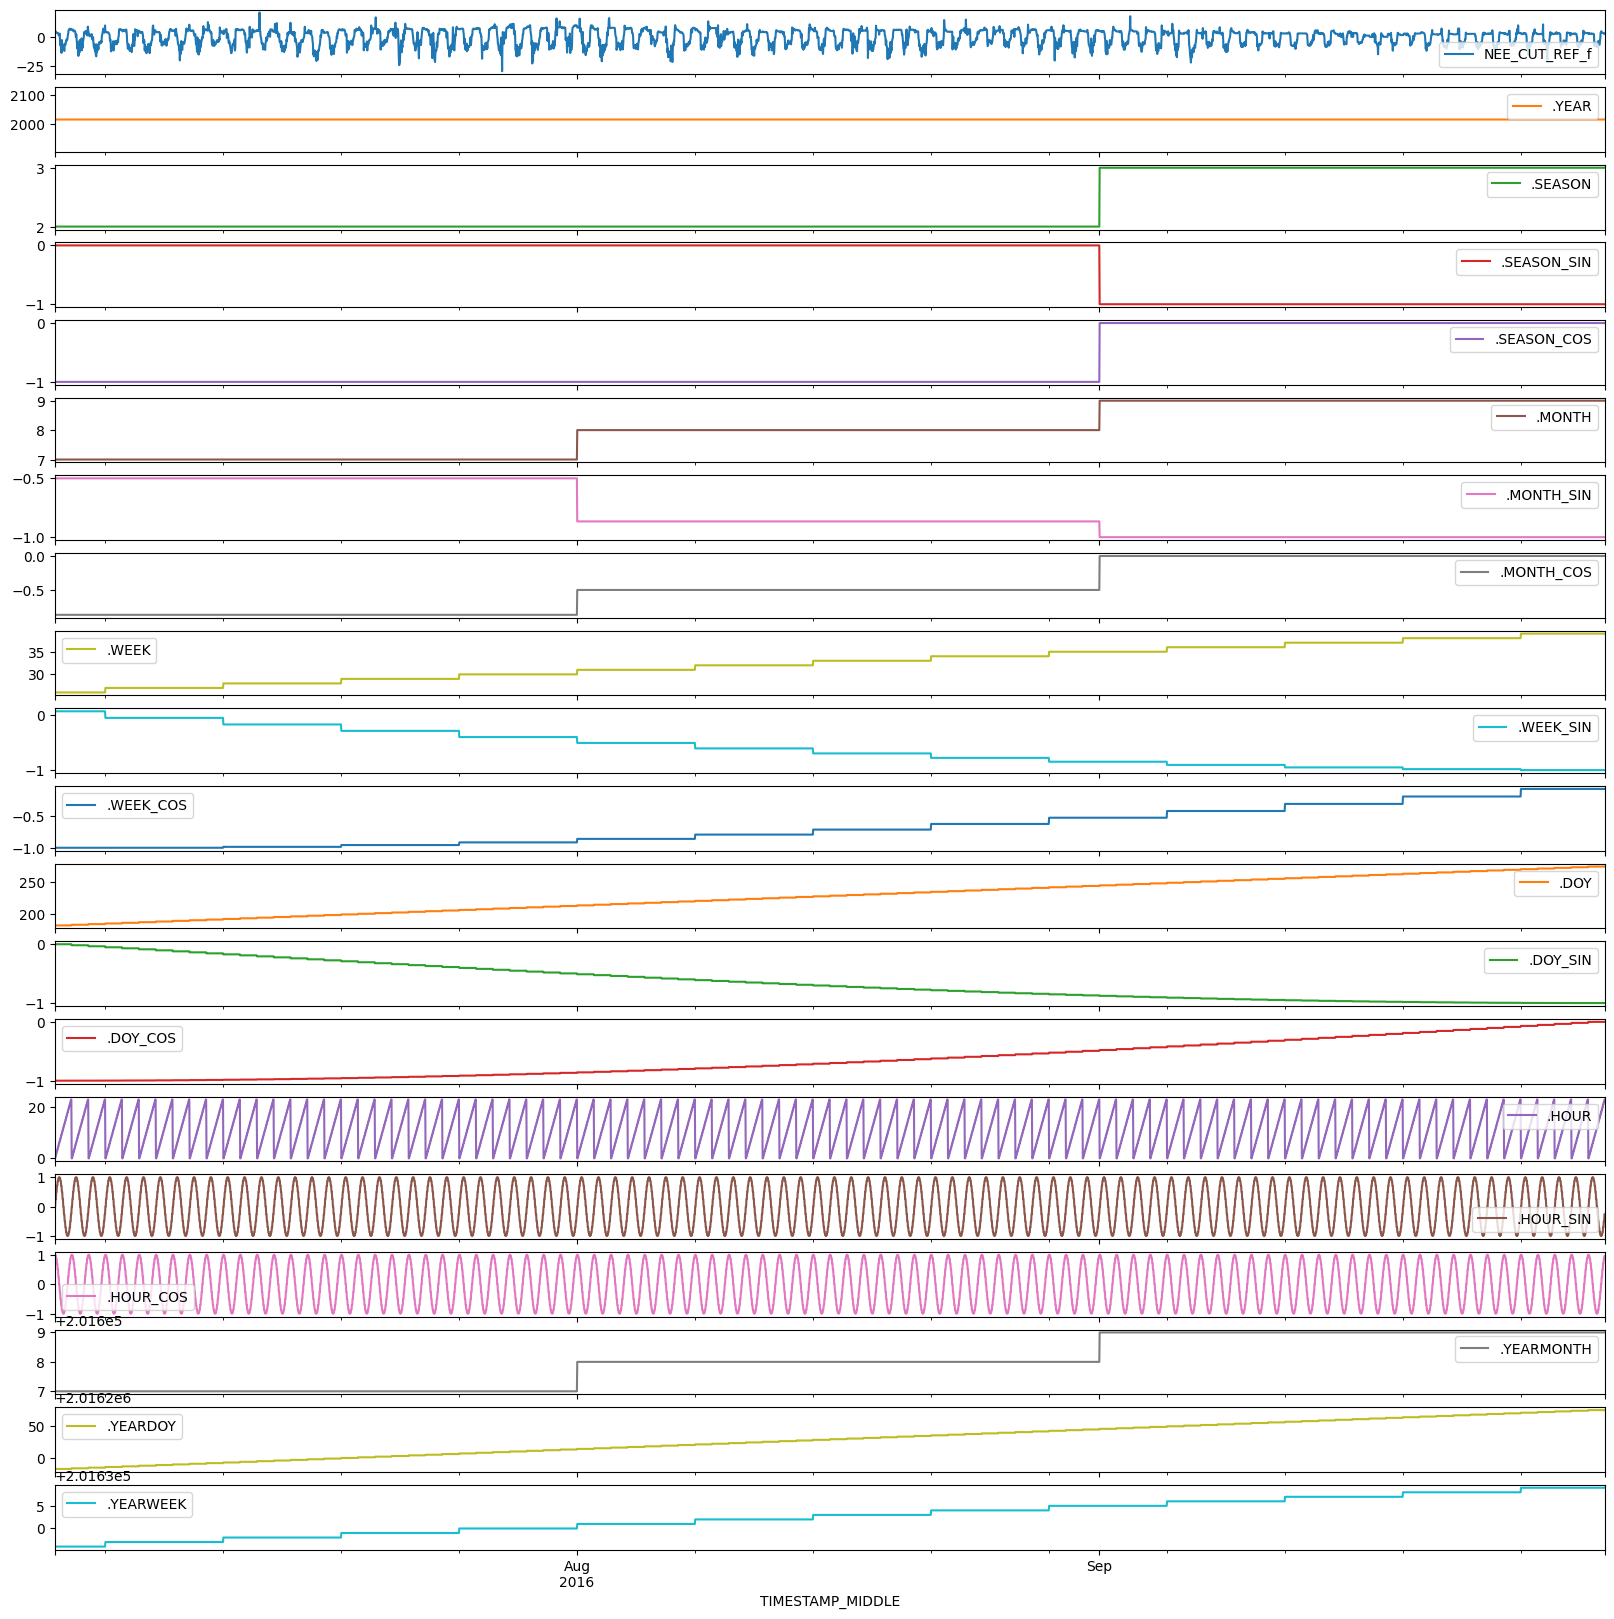

In [5]:
new_df.plot(figsize=(20, 20), subplots=True);

</br>

# End of notebook

In [6]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished {dt_string}")

Finished 2026-01-05 23:22:08
